In [1]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
slug = "fed-decision-in-july-181"

url = f"https://gamma-api.polymarket.com/events?slug={slug}"
response = requests.get(url)
data = response.json()

print(json.dumps(data, indent=2))

[
  {
    "id": "287395",
    "ticker": "fed-decision-in-july-181",
    "slug": "fed-decision-in-july-181",
    "title": "Fed Decision in July?",
    "description": "The FED interest rates are defined in this market by the upper bound of the target federal funds range. The decisions on the target federal funds range are made by the Federal Open Market Committee (FOMC) meetings.\n\nThis market will resolve to the amount of basis points the upper bound of the target federal funds rate is changed by versus the level it was prior to the Federal Reserve's July 2026 meeting.\n\nIf the target federal funds rate is changed to a level not expressed in the displayed options, the change will be rounded up to the nearest 25 and will resolve to the relevant bracket. (e.g. if there's a cut/increase of 12.5 bps it will be considered to be 25 bps)\n\nThe resolution source for this market is the FOMC\u2019s statement after its meeting scheduled for July 28-29, 2026 according to the official calendar: h

In [3]:
event = data[0]

for market in event['markets']:
    print(market['groupItemTitle'])

50+ bps decrease
25 bps decrease
No change
25 bps increase
50+ bps increase


In [4]:
for market in event['markets']:
    if market['groupItemTitle'] == 'No change':
        target_market = market

In [5]:
print(json.dumps(target_market, indent=2))

{
  "id": "1654958",
  "question": "Will there be no change in Fed interest rates after the July 2026 meeting?",
  "conditionId": "0x8bf1c1536ecb1c08fe13c6b71e8ab1f58bf3461c4cb79f5f1679f869a06aef86",
  "slug": "will-there-be-no-change-in-fed-interest-rates-after-the-july-2026-meeting",
  "endDate": "2026-07-29T00:00:00Z",
  "startDate": "2026-03-20T00:12:44.271047Z",
  "image": "https://polymarket-upload.s3.us-east-2.amazonaws.com/jerome+powell+glasses1.png",
  "icon": "https://polymarket-upload.s3.us-east-2.amazonaws.com/jerome+powell+glasses1.png",
  "description": "The FED interest rates are defined in this market by the upper bound of the target federal funds range. The decisions on the target federal funds range are made by the Federal Open Market Committee (FOMC) meetings.\n\nThis market will resolve to the amount of basis points the upper bound of the target federal funds rate is changed by versus the level it was prior to the Federal Reserve's July 2026 meeting.\n\nIf the targe

In [6]:
condition_id = target_market['conditionId']
clob_token_ids = target_market['clobTokenIds']
clob_token_ids = json.loads(clob_token_ids)

print(condition_id)
print(clob_token_ids)

0x8bf1c1536ecb1c08fe13c6b71e8ab1f58bf3461c4cb79f5f1679f869a06aef86
['111604417349377875799825956621596386269673370070912696668140891647145772186047', '36015050921127306245266044699797268780268172446856063291868548314968920497494']


In [7]:
yes_token_id = clob_token_ids[0]

clob_url = "https://clob.polymarket.com/prices-history"
params = {
    "market": yes_token_id,
    "interval": "max",
    "fidelity": 1
}

response = requests.get(clob_url, params=params)
history = response.json()

print(history)

{'history': [{'t': 1784223011, 'p': 0.957}, {'t': 1784223606, 'p': 0.9565}, {'t': 1784224204, 'p': 0.9555}, {'t': 1784224824, 'p': 0.9565}, {'t': 1784225406, 'p': 0.956}, {'t': 1784226007, 'p': 0.9565}, {'t': 1784226608, 'p': 0.9575}, {'t': 1784227219, 'p': 0.9575}, {'t': 1784227806, 'p': 0.9575}, {'t': 1784228408, 'p': 0.9575}, {'t': 1784229005, 'p': 0.9575}, {'t': 1784229606, 'p': 0.9575}, {'t': 1784230207, 'p': 0.9575}, {'t': 1784230804, 'p': 0.9575}, {'t': 1784231405, 'p': 0.9575}, {'t': 1784232009, 'p': 0.9575}, {'t': 1784232605, 'p': 0.9575}, {'t': 1784233204, 'p': 0.9575}, {'t': 1784233808, 'p': 0.9575}, {'t': 1784234406, 'p': 0.9575}, {'t': 1784235004, 'p': 0.9575}, {'t': 1784235611, 'p': 0.9575}, {'t': 1784236205, 'p': 0.9575}, {'t': 1784236804, 'p': 0.9575}, {'t': 1784237407, 'p': 0.9575}, {'t': 1784238005, 'p': 0.9575}, {'t': 1784238605, 'p': 0.9575}, {'t': 1784239208, 'p': 0.9575}, {'t': 1784239805, 'p': 0.9575}, {'t': 1784240405, 'p': 0.9575}, {'t': 1784241019, 'p': 0.9575

In [8]:
df = pd.DataFrame(history['history'])
df['datetime'] = pd.to_datetime(df['t'], unit='s')
df['datetime'] = df['datetime'].dt.tz_localize('UTC').dt.tz_convert('America/New_York')
df.head()

,t,p,datetime
0,1784223011,0.9570,2026-07-16 13:30:11-04:00
1,1784223606,0.9565,2026-07-16 13:40:06-04:00
2,1784224204,0.9555,2026-07-16 13:50:04-04:00
3,1784224824,0.9565,2026-07-16 14:00:24-04:00
4,1784225406,0.9560,2026-07-16 14:10:06-04:00


In [9]:
window_df = df[(df['datetime'] >= '2026-07-29 12:00:00') & (df['datetime'] <= '2026-07-29 16:00:00')]
window_df = window_df.rename(columns={'t': 'unix_timestamp', 'p': 'implied_probability_no_change'})
print(window_df.head())
print(window_df.tail())

      unix_timestamp  implied_probability_no_change                  datetime
1824      1785341444                         0.7245 2026-07-29 12:10:44-04:00
1825      1785342036                         0.7275 2026-07-29 12:20:36-04:00
1826      1785343235                         0.7405 2026-07-29 12:40:35-04:00
1827      1785343829                         0.7465 2026-07-29 12:50:29-04:00
1828      1785345038                         0.7425 2026-07-29 13:10:38-04:00
      unix_timestamp  implied_probability_no_change                  datetime
1838      1785352210                         0.9995 2026-07-29 15:10:10-04:00
1839      1785352812                         0.9995 2026-07-29 15:20:12-04:00
1840      1785353419                         0.9995 2026-07-29 15:30:19-04:00
1841      1785354012                         0.9995 2026-07-29 15:40:12-04:00
1842      1785354611                         0.9995 2026-07-29 15:50:11-04:00


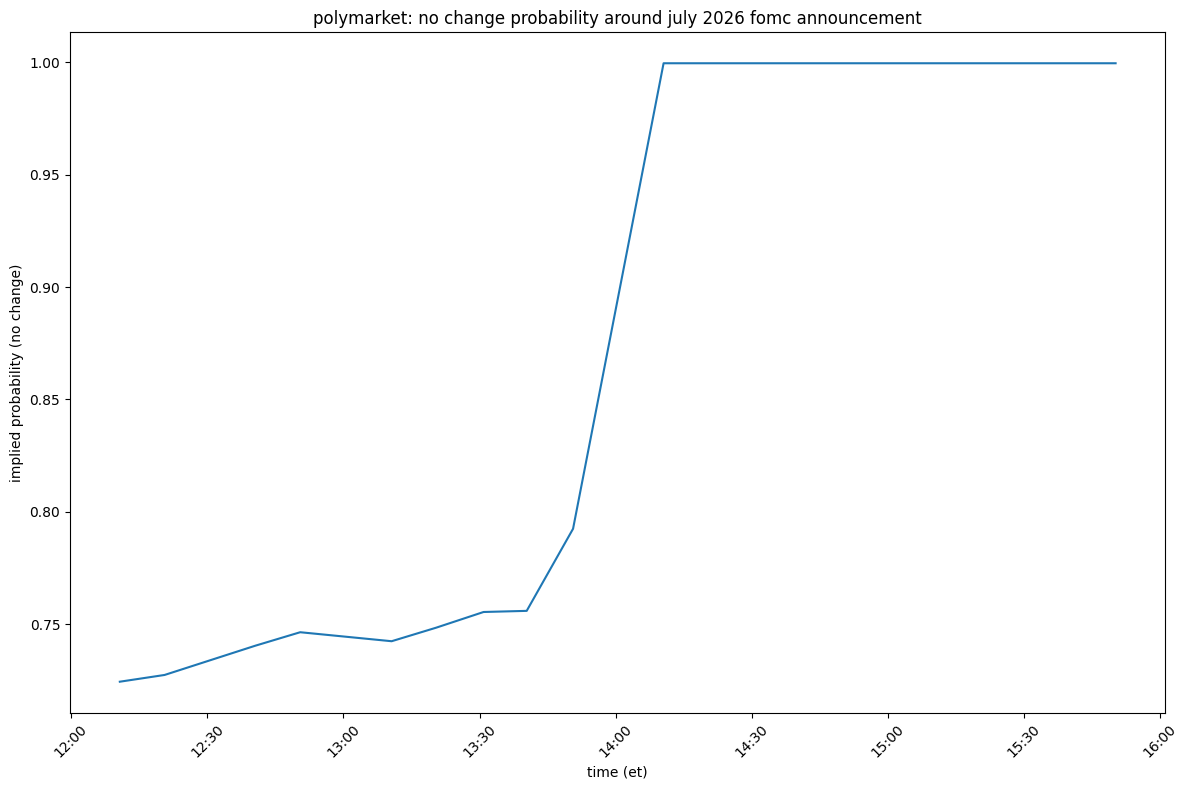

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(window_df['datetime'], window_df['implied_probability_no_change'])
ax.set_title('polymarket: no change probability around july 2026 fomc announcement')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied probability (no change)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=window_df['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()